# 01 — EDA and feature-engineering evidence
This notebook reads a bounded TRAIN sample from the certified independent Python delay handoff and checks persisted verification evidence. Plots describe this sample only. Raw production data is never loaded here.

References: [feature contract](../documentation/FEATURE_ENGINEERING_CONTRACT.md), [data dictionary](../documentation/DATA_DICTIONARY.md), [ML handoff](../ml_execution/README.md).


In [1]:
from pathlib import Path
import sys, json, hashlib, platform
REPO = Path('/home/manal/Desktop/UrbanTransit-IQ').resolve()
assert (REPO / 'feature_contracts.py').is_file(), 'Set REPO to the authoritative checkout'
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
def small_json(path, limit=2_000_000):
    path = Path(path).resolve()
    if 'raw_data' in path.parts: raise ValueError('Processed evidence only')
    with path.open('rb') as stream: payload = stream.read(limit + 1)
    if len(payload) > limit: raise ValueError('JSON exceeds notebook evidence size limit')
    return json.loads(payload)
print({'python': platform.python_version(), 'repo': str(REPO),
       'feature_contract_sha256': hashlib.sha256((REPO/'feature_contracts.py').read_bytes()).hexdigest()})


{'python': '3.10.12', 'repo': '/home/manal/Desktop/UrbanTransit-IQ', 'feature_contract_sha256': '2450437b27868be67361b78944ce7bb1c8bd575dab77b3a0e5e108a2447b13d1'}


## 1. Task definitions, grain, targets and leakage rules
Read the shared code contract so this notebook follows the current implementation.
Spark writes `<features-root>/task=<task>/split=<split>` Parquet; Python's
`OutputContract.split(task, split)` is `<processed-root>/ml/<task>/<split>`.
These paths are contracts, not assertions that publication has finished.
`demand_forecast` feature output and `passenger_demand` ML task names differ;
the certified adapter must map them explicitly. Descriptive occupancy is not an occupancy forecast.


In [2]:
from dataclasses import asdict
from feature_contracts import FEATURE_CONTRACTS, CHRONOLOGICAL_SPLITS
for name, contract in FEATURE_CONTRACTS.items():
    print(name, json.dumps(asdict(contract), indent=2))
print('Half-open service-date periods:', CHRONOLOGICAL_SPLITS)


delay_severity {
  "name": "delay_severity",
  "output_features": [
    "scheduled_hour_utc",
    "service_weekday",
    "is_weekend",
    "service_month",
    "historical_delay_sec_lag_1",
    "historical_delay_sec_mean_7",
    "planned_vehicle_status",
    "planned_vehicle_type",
    "known_context_event_count",
    "delay_sec",
    "delay_severity"
  ],
  "predictor_features": [
    "route_id",
    "route_code",
    "mode",
    "service_type",
    "pattern_id",
    "direction_id",
    "stop_id",
    "stop_sequence",
    "distance_km",
    "planned_vehicle_status",
    "planned_vehicle_type",
    "known_context_event_count",
    "scheduled_departure_utc",
    "scheduled_hour_utc",
    "service_weekday",
    "is_weekend",
    "service_month",
    "historical_delay_sec_lag_1",
    "historical_delay_sec_mean_7"
  ],
  "source_tables": [
    "trips",
    "trip_stop_events",
    "route_patterns",
    "route_stops",
    "routes",
    "schedules",
    "schedule_stop_times",
    "context_eve

## 2. Certified completed input and bounded sampling
Read the first 5,000 rows of the certified Python delay training JSONL. Verify the original partition hash before sampling. This deterministic prefix is diagnostic and is not a population estimate. Targets retain the handoff's explicit class vocabulary; no labels are derived here.

In [3]:
import pandas as pd
from ml_execution.contracts import contract_digest
FEATURE_MANIFEST = REPO / 'reports/ml_handoffs/python-delay-severity-prod-v11-20260928T1935Z/manifest.json'
manifest = small_json(FEATURE_MANIFEST)
evidence_path = FEATURE_MANIFEST.parent / manifest['certification']['evidence_path']
evidence = small_json(evidence_path)
assert evidence['status'] == 'CERTIFIED' and evidence['contract_sha256'] == contract_digest(manifest)
assert evidence['partitions'] == manifest['partitions']
assert manifest['producer'] == 'python'
path = (FEATURE_MANIFEST.parent / manifest['partitions']['train']['path']).resolve()
assert path.is_relative_to(FEATURE_MANIFEST.parent.resolve()) and 'raw_data' not in path.parts
h = hashlib.sha256()
with path.open('rb') as stream:
    for block in iter(lambda: stream.read(1024 * 1024), b''): h.update(block)
assert h.hexdigest() == manifest['partitions']['train']['sha256']
MAX_ROWS = 5000
EDA_COLUMNS = ['service_date', *manifest['features'], manifest['target']]
assert len(EDA_COLUMNS) <= 16
rows = []
with path.open() as stream:
    for line in stream:
        row = json.loads(line)
        rows.append({key: row[key] for key in EDA_COLUMNS})
        if len(rows) == MAX_ROWS: break
frame = pd.DataFrame(rows)
frame['delay_severity'] = frame[manifest['target']].map(dict(enumerate(manifest['class_labels'])))
dates = pd.to_datetime(frame.service_date, errors='raise')
lo, hi = CHRONOLOGICAL_SPLITS['train']
assert ((dates >= lo) & (dates < hi)).all()
sample_provenance = {'status': 'VERIFIED_BOUNDED_TRAIN_SAMPLE', 'path': str(path),
    'sha256': h.hexdigest(), 'rows_loaded': len(frame), 'manifest': str(FEATURE_MANIFEST),
    'sampling': 'first 5000 sorted training rows; not population estimates', 'class_labels': manifest['class_labels']}
display(sample_provenance)


{'status': 'VERIFIED_BOUNDED_TRAIN_SAMPLE',
 'path': '/home/manal/Desktop/UrbanTransit-IQ/reports/ml_handoffs/python-delay-severity-prod-v11-20260928T1935Z/train.jsonl',
 'sha256': '909340b4372032e565d3c8158612ddeae8a4b87f617d04c7edee5de219a28b8c',
 'rows_loaded': 5000,
 'manifest': '/home/manal/Desktop/UrbanTransit-IQ/reports/ml_handoffs/python-delay-severity-prod-v11-20260928T1935Z/manifest.json',
 'sampling': 'first 5000 sorted training rows; not population estimates',
 'class_labels': ['ON_TIME', 'MINOR_DELAY', 'MODERATE_DELAY']}

## 3. Sample EDA: missingness, distributions, dates and duplicate diagnostics
Every table/plot below describes only the loaded sample. Missing history is not zero.
Review configurable severity thresholds with the feature evidence before interpreting labels.


,service_date,scheduled_hour_utc,service_weekday,is_weekend,service_month,direction_id,distance_km,target,delay_severity
0,2025-01-01,1.0,3.0,0.0,1.0,0.0,82.812,1,MINOR_DELAY
1,2025-01-01,1.0,3.0,0.0,1.0,0.0,82.812,1,MINOR_DELAY
2,2025-01-01,1.0,3.0,0.0,1.0,0.0,115.813,1,MINOR_DELAY
3,2025-01-01,1.0,3.0,0.0,1.0,0.0,112.283,1,MINOR_DELAY
4,2025-01-01,1.0,3.0,0.0,1.0,0.0,82.812,1,MINOR_DELAY
5,2025-01-01,1.0,3.0,0.0,1.0,0.0,108.637,1,MINOR_DELAY
6,2025-01-01,1.0,3.0,0.0,1.0,0.0,112.464,1,MINOR_DELAY
7,2025-01-01,1.0,3.0,0.0,1.0,0.0,79.463,1,MINOR_DELAY
8,2025-01-01,1.0,3.0,0.0,1.0,0.0,79.282,1,MINOR_DELAY
9,2025-01-01,1.0,3.0,0.0,1.0,0.0,108.637,1,MINOR_DELAY


,sample_null_count
service_date,0
scheduled_hour_utc,0
service_weekday,0
is_weekend,0
service_month,0
direction_id,0
distance_km,0
target,0
delay_severity,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
service_date,5000,28,2025-01-25,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_hour_utc,5000.0,NaN,NaN,NaN,2.693,1.192911,1.0,2.0,3.0,4.0,7.0
service_weekday,5000.0,NaN,NaN,NaN,4.0668,1.996581,1.0,2.0,4.0,6.0,7.0
is_weekend,5000.0,NaN,NaN,NaN,0.2988,0.457778,0.0,0.0,0.0,1.0,1.0
service_month,5000.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
direction_id,5000.0,NaN,NaN,NaN,0.4868,0.499876,0.0,0.0,0.0,1.0,1.0
distance_km,5000.0,NaN,NaN,NaN,105.695872,14.876331,75.933,95.357,105.585,118.13,128.539
target,5000.0,NaN,NaN,NaN,1.2886,0.722367,0.0,1.0,1.0,2.0,2.0
delay_severity,5000,3,MODERATE_DELAY,2234,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Exact projected duplicate rows (not duplicate source keys): 2255
Sample service-date range: 2025-01-01 2025-01-28


,sample_count
delay_severity,
MODERATE_DELAY,2234
MINOR_DELAY,1975
ON_TIME,791


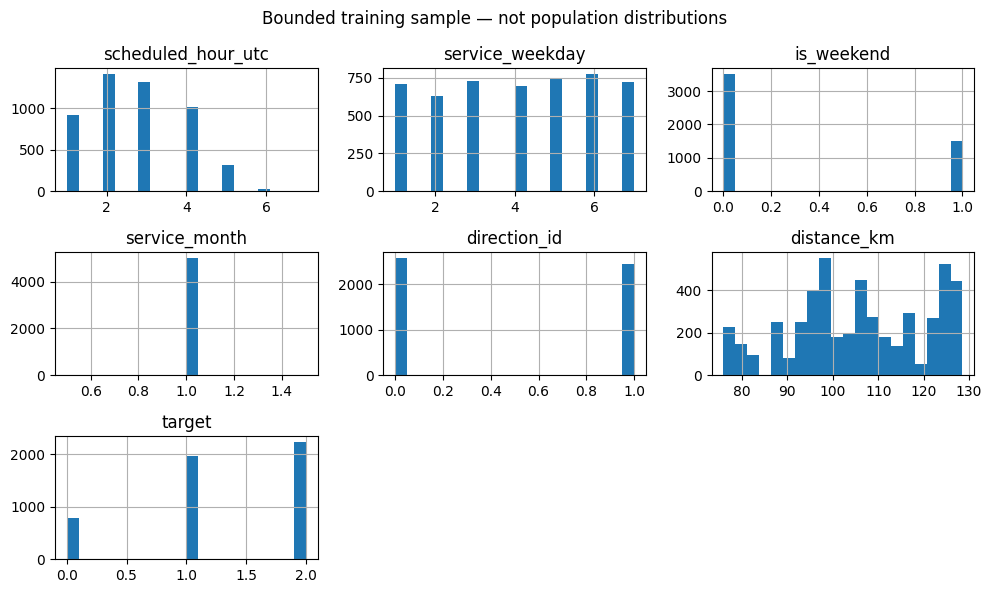

In [4]:
if frame is None:
    print('PENDING: completed bounded training features')
else:
    display(frame.head(10))
    display(frame.isna().sum().rename('sample_null_count').to_frame())
    display(frame.describe(include='all').T)
    print('Exact projected duplicate rows (not duplicate source keys):', int(frame.duplicated().sum()))
    print('Sample service-date range:', frame.service_date.min(), frame.service_date.max())
    if 'delay_severity' in frame:
        display(frame.delay_severity.value_counts(dropna=False).rename('sample_count').to_frame())
    numeric = frame.select_dtypes(include='number')
    if not numeric.empty:
        import matplotlib.pyplot as plt
        numeric.hist(bins=20, figsize=(10, 6))
        plt.suptitle('Bounded training sample — not population distributions')
        plt.tight_layout(); plt.show()


## 4. Persisted dataset verification
Read the 42-check bounded verification report and confirm its hash against the owner's attestation. This is evidence inspection, not a rerun of raw-data verification. The documented GPS-to-stop limitation remains: the raw GPS contract has no stop foreign key.

In [5]:
report_path = REPO / 'reports/production_v11_bounded_verification.json'
attestation = small_json(REPO / 'reports/dataset_certification/production-v1.1-owner-attestation.json')
assert hashlib.sha256(report_path.read_bytes()).hexdigest() == attestation['evidence_sha256']['verification_report']
report = small_json(report_path)
assert report['passed'] and len(report['checks']) == 42 and all(c['passed'] for c in report['checks'])
display(pd.DataFrame([{'check': c['name'], 'passed': c['passed']} for c in report['checks']]))
print(attestation['approval_statement'])


,check,passed
0,production_v1_integrity_unchanged,True
1,parent_only_preexisting_metadata_declaration,True
2,hard_link_and_replace_split,True
3,no_second_physical_copy,True
4,manifest_hash_consistency,True
5,manifest_self_hash,True
6,manifest_deterministic_hash,True
7,corrected_version_lineage,True
8,operated_departures,True
9,operational_stop_coverage,True


I approve production-v1.1 (correction production-v1.1-correction-v1; run RUN498f509222a2382c01b5c865f2a7174404f0d3a676128f4d01078ea8968ff8e9), derived from production-v1, for downstream independent Python feature engineering and ML use, based on the bound v1.1 generation/remediation provenance and reports/production_v11_bounded_verification.json with 42/42 checks passing. I acknowledge that this is project-generated synthetic data; the earlier production-v1 validation failed and its reuse report is not a passing v1.1 validation; this scoped bounded verification does not reconcile GPS coordinates to stops (the raw GPS contract has no stop foreign key) or constitute external or real-world validation. This attestation does not modify the dataset files.


## 5. Chronology and limits
TRAIN is 2025; VALIDATION is January–March 2026; TEST is April–June 2026. The model handoff enforces chronology, identity, finite predictors and availability. Notebook 02 reads completed model results and audits the preserved comparison.

The plots above describe only a deterministic training prefix. They do not establish complete SRS DQ coverage or full-scale modelling. Certification is scoped to the owner's bounded verification; synthetic-data and GPS limitations remain.